# 🔬 Embryo Morphokinetic Stage Classification — LSTM (Sequence Model)
**Dataset:** Embryo time-lapse (same Kaggle dataset)  
**Approach:** Each embryo video → sequence of up to 6 consecutive frames → LSTM classifies the stage  



---
## 💡 Why LSTM for Embryo Stages?

Each embryo video is a **time-ordered sequence** of frames. A single frame may be ambiguous,
but looking at **6 consecutive frames** gives the model temporal context — it can see
*how the embryo is changing*, not just what it looks like at one moment.

**Sequence construction:**
- For each labeled frame, we take that frame + up to 5 previous frames from the same video
- Each frame is passed through a **CNN feature extractor** (MobileNetV2 frozen) → 1280-dim vector
- The 6 vectors form a sequence fed into the **LSTM**
- The LSTM output is classified into one of 16 morphokinetic phases


---
## 📦 Section 0 — Setup

In [1]:
import os, sys, warnings, gc, random, re
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'scikit-learn', 'seaborn', 'tqdm'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, backend as K
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, Callback
)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)
    print(f'  {g}')

keras.mixed_precision.set_global_policy('mixed_float16')
print('Mixed precision: ON')
print('✅ Setup complete')


E0000 00:00:1776748056.704298      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776748056.749653      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776748057.101813      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776748057.101850      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776748057.101857      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776748057.101859      55 computation_placer.cc:177] computation placer already registered. Please check linka

TensorFlow: 2.19.0
GPUs available: 2
  PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
  PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')
Mixed precision: ON
✅ Setup complete


---
## 📁 Section 1 — Configuration

In [2]:
BASE_DIR    = Path('/kaggle/working')
CKPT_DIR    = BASE_DIR / 'checkpoints'
LOG_DIR     = BASE_DIR / 'logs'
RESULTS_DIR = BASE_DIR / 'results'
CACHE_DIR   = BASE_DIR / 'cache'
for d in [CKPT_DIR, LOG_DIR, RESULTS_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

KAGGLE_INPUT = Path('/kaggle/input')
print('=== /kaggle/input contents ===')
for p in KAGGLE_INPUT.iterdir():
    print(f'  {p}')

# ── Auto-locate dataset ────────────────────────────────────────────────────────
IMAGES_DIR = next((c for c in KAGGLE_INPUT.rglob('embryo_dataset')
                   if c.is_dir() and any(c.iterdir())), None)
ANNOTS_DIR = next((c for c in KAGGLE_INPUT.rglob('embryo_dataset_annotations')
                   if c.is_dir()), None)

if IMAGES_DIR:
    sub = IMAGES_DIR / 'embryo_dataset'
    if sub.exists(): IMAGES_DIR = sub

if not IMAGES_DIR or not ANNOTS_DIR:
    import tarfile
    DATA_DIR = BASE_DIR / 'embryo_data'
    DATA_DIR.mkdir(exist_ok=True)
    img_tar = next(KAGGLE_INPUT.rglob('embryo_dataset.tar.gz'), None)
    ann_tar = next(KAGGLE_INPUT.rglob('embryo_dataset_annotations.tar.gz'), None)
    def _extract(tp, dest, marker):
        m = dest / marker
        if m.exists(): print(f'  Already extracted: {marker}'); return m
        print(f'  Extracting {tp.name}...')
        with tarfile.open(tp, 'r:gz') as tar:
            for mem in tqdm(tar.getmembers(), desc='Extracting', mininterval=2):
                tar.extract(mem, path=dest, set_attrs=False)
        return m
    if img_tar: IMAGES_DIR = _extract(img_tar, DATA_DIR, 'embryo_dataset')
    if ann_tar: ANNOTS_DIR = _extract(ann_tar, DATA_DIR, 'embryo_dataset_annotations')

assert IMAGES_DIR and ANNOTS_DIR, '❌ Dataset not found.'
print(f'\n✅ Images : {IMAGES_DIR}')
print(f'✅ Annots : {ANNOTS_DIR}')

# ── Classes ────────────────────────────────────────────────────────────────────
PHASE_LABELS = [
    'pPB2','pPNa','pPNf',
    'p2','p3','p4','p5','p6','p7','p8','p9+',
    'pM','pSB','pB','pEB','pHB'
]
NUM_CLASSES = len(PHASE_LABELS)
LABEL2IDX = {}
for i, pl in enumerate(PHASE_LABELS):
    LABEL2IDX[pl] = i
    LABEL2IDX[pl.replace('p','t',1)] = i
IDX2LABEL = {i: PHASE_LABELS[i] for i in range(NUM_CLASSES)}

# ── Hyperparameters ────────────────────────────────────────────────────────────
IMG_SIZE      = (128, 128)   # smaller → faster feature extraction
SEQ_LEN       = 6            # maximum frames per sequence
FEATURE_DIM   = 1280         # MobileNetV2 output channels
BATCH_SIZE    = 32
EPOCHS        = 15
LEARNING_RATE = 3e-4
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15

print(f'\nClasses     : {NUM_CLASSES}')
print(f'Sequence len: {SEQ_LEN} frames max')
print(f'Image size  : {IMG_SIZE}')


=== /kaggle/input contents ===
  /kaggle/input/datasets

✅ Images : /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset/embryo_dataset
✅ Annots : /kaggle/input/datasets/abhishekbuddiga06/embryo-dataset/embryo_dataset_annotations

Classes     : 16
Sequence len: 6 frames max
Image size  : (128, 128)


---
## 🗂️ Section 2 — Parse Annotations & Build Sequence Dataset

In [3]:
def is_valid_jpeg(path):
    """Check JPEG has proper end-of-image marker (0xFF 0xD9)."""
    try:
        with open(path, 'rb') as f:
            f.seek(-2, 2)
            return f.read(2) == b'\xff\xd9'
    except Exception:
        return False


def parse_annotations(annots_dir):
    """Parse all CSV files → {video_id: [(label, start, end), ...]}"""
    ann_map = {}
    csv_files = sorted(annots_dir.glob('**/*.csv')) or sorted(annots_dir.glob('*.csv'))
    print(f'Found {len(csv_files)} annotation CSV files.')
    for csv_path in csv_files:
        video_id = csv_path.stem.replace('_phases', '')
        phases = []
        for line in csv_path.read_text().strip().splitlines():
            parts = line.split() if ',' not in line else line.split(',')
            if len(parts) < 3: continue
            try:
                phases.append((parts[0].strip(), int(parts[1]), int(parts[2])))
            except ValueError:
                continue
        phases.sort(key=lambda x: x[1])
        ann_map[video_id] = phases
    return ann_map


def frame_to_label(frame_idx, phases):
    current = None
    for label, start, end in phases:
        if frame_idx >= start: current = label
        else: break
    return current


VALID_CACHE = CACHE_DIR / 'valid_frames.csv'

def build_frame_df(images_dir, annots_dir):
    """Build a DataFrame of all valid labeled frames with their video_id and frame_idx."""
    if VALID_CACHE.exists():
        print(f'Loading cached frame list from {VALID_CACHE}')
        return pd.read_csv(VALID_CACHE)

    ann_map = parse_annotations(annots_dir)
    video_dirs = sorted(d for d in images_dir.iterdir() if d.is_dir())
    print(f'Found {len(video_dirs)} video folders.')

    records, bad = [], 0
    for vd in tqdm(video_dirs, desc='Scanning frames'):
        vid = vd.name
        if vid not in ann_map or not ann_map[vid]: continue
        phases = ann_map[vid]
        imgs = sorted(vd.glob('*.jpeg')) or sorted(vd.glob('*.jpg'))
        for img_path in imgs:
            if not is_valid_jpeg(img_path): bad += 1; continue
            digits = re.findall(r'\d+', img_path.stem)
            fidx = int(digits[-1]) if digits else 0
            raw = frame_to_label(fidx, phases)
            if not raw or raw not in LABEL2IDX: continue
            li = LABEL2IDX[raw]
            records.append({'filepath': str(img_path), 'video_id': vid,
                            'frame_idx': fidx, 'label': IDX2LABEL[li], 'label_idx': li})

    df = pd.DataFrame(records)
    df.to_csv(VALID_CACHE, index=False)
    print(f'Corrupt JPEGs removed : {bad:,}')
    print(f'Valid labeled frames  : {len(df):,}')
    return df


frame_df = build_frame_df(IMAGES_DIR, ANNOTS_DIR)
print('\nClass distribution:')
print(frame_df['label'].value_counts().reindex(PHASE_LABELS))


Found 704 annotation CSV files.
Found 704 video folders.


Scanning frames:   0%|          | 0/704 [00:00<?, ?it/s]

Corrupt JPEGs removed : 27,659
Valid labeled frames  : 306,296

Class distribution:
label
pPB2     8253
pPNa    39652
pPNf     6333
p2      27134
p3       4530
p4      27246
p5       7080
p6       7799
p7      10119
p8      31834
p9+     53283
pM      19965
pSB     19156
pB      10426
pEB     33389
pHB        97
Name: count, dtype: int64


---
## 🔗 Section 3 — Build Sequences (up to 6 frames per sample)

For each labeled frame we look back up to `SEQ_LEN-1` frames in the same video.
Short sequences (near the start of a video) are **zero-padded** on the left.


In [4]:
def build_sequences(frame_df, seq_len=SEQ_LEN):
    """
    For every frame, collect the previous (seq_len-1) frames from the same video.
    Returns list of (sequence_of_paths, label_idx).
    Shorter sequences are left-padded with empty string (handled in loader).
    """
    sequences = []
    # Group by video, sort by frame_idx
    for vid, grp in tqdm(frame_df.groupby('video_id'), desc='Building sequences'):
        grp = grp.sort_values('frame_idx').reset_index(drop=True)
        paths  = grp['filepath'].tolist()
        labels = grp['label_idx'].tolist()
        for i in range(len(paths)):
            # Take up to seq_len frames ending at index i
            start = max(0, i - seq_len + 1)
            seq   = paths[start : i + 1]
            # Left-pad with empty string if sequence is shorter than seq_len
            pad   = [''] * (seq_len - len(seq))
            sequences.append((pad + seq, labels[i]))

    print(f'Total sequences: {len(sequences):,}')
    return sequences


all_sequences = build_sequences(frame_df)

# ── Train / Val / Test split at VIDEO level ────────────────────────────────────
rng       = np.random.default_rng(SEED)
video_ids = rng.permutation(frame_df['video_id'].unique())
n         = len(video_ids)
n_test    = int(n * TEST_SPLIT)
n_val     = int(n * VAL_SPLIT)

train_vids = set(video_ids[:n - n_test - n_val])
val_vids   = set(video_ids[n - n_test - n_val : n - n_test])
test_vids  = set(video_ids[n - n_test:])

# Map each sequence to its split using its video_id
# sequences list has no direct video_id — rebuild with it
seq_records = []
for vid, grp in frame_df.groupby('video_id'):
    grp  = grp.sort_values('frame_idx').reset_index(drop=True)
    paths  = grp['filepath'].tolist()
    labels = grp['label_idx'].tolist()
    for i in range(len(paths)):
        start = max(0, i - SEQ_LEN + 1)
        seq   = paths[start:i+1]
        pad   = [''] * (SEQ_LEN - len(seq))
        seq_records.append({'video_id': vid, 'seq': pad + seq, 'label_idx': labels[i]})

seq_df     = pd.DataFrame(seq_records)
train_seq  = seq_df[seq_df['video_id'].isin(train_vids)].reset_index(drop=True)
val_seq    = seq_df[seq_df['video_id'].isin(val_vids)].reset_index(drop=True)
test_seq   = seq_df[seq_df['video_id'].isin(test_vids)].reset_index(drop=True)

print(f'Train sequences: {len(train_seq):,}')
print(f'Val   sequences: {len(val_seq):,}')
print(f'Test  sequences: {len(test_seq):,}')

# Class weights
present = np.sort(train_seq['label_idx'].unique())
w_part  = compute_class_weight('balanced', classes=present, y=train_seq['label_idx'].values)
cw_arr  = np.full(NUM_CLASSES, w_part.max())
for cls, w in zip(present, w_part): cw_arr[cls] = w
print('\nClass weights computed ✅')


Building sequences:   0%|          | 0/652 [00:00<?, ?it/s]

Total sequences: 306,296
Train sequences: 215,342
Val   sequences: 45,560
Test  sequences: 45,394

Class weights computed ✅


---
## 📊 Section 4 — Exploratory Data Analysis

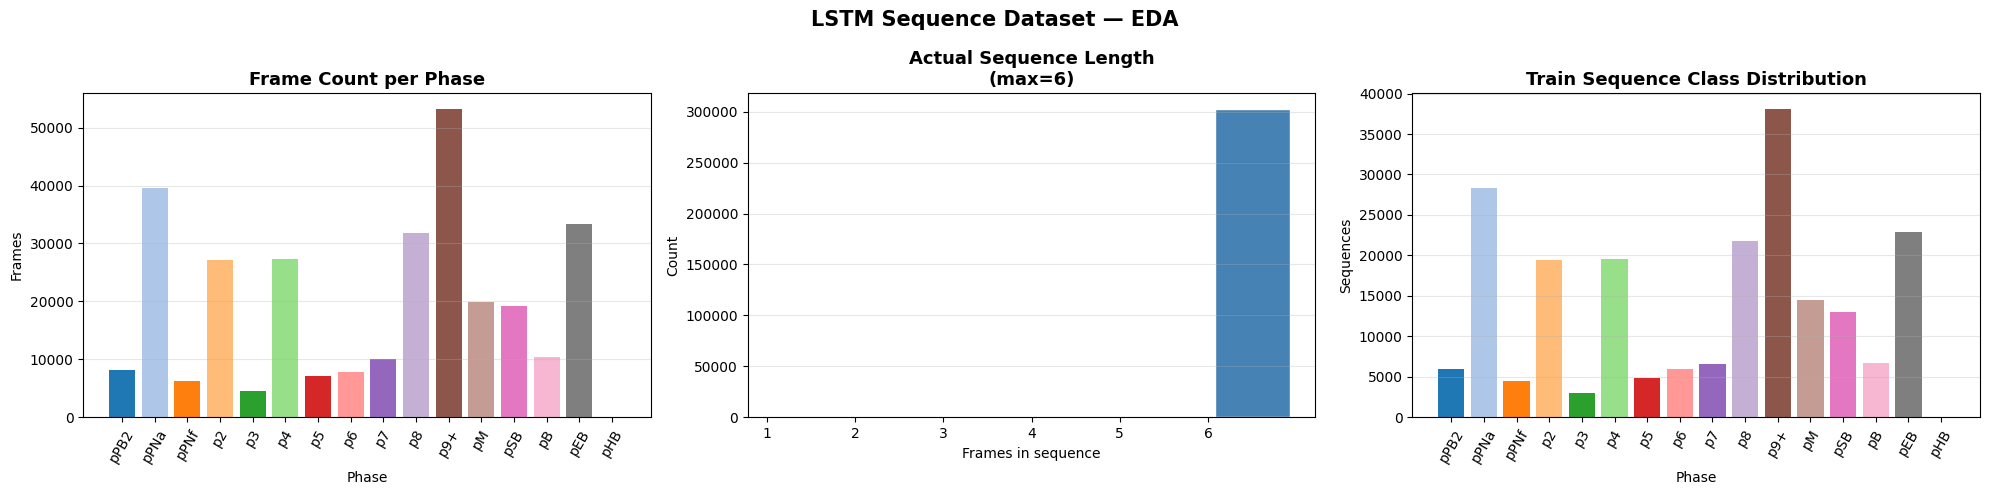

Total videos : 652
Total frames : 306,296
Total seqs   : 306,296
Fully padded sequences (len=1): 652
Full length sequences (len=6): 303,036


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Class distribution in full frame_df
counts = frame_df['label'].value_counts().reindex(PHASE_LABELS).fillna(0).astype(int)
colors = plt.cm.tab20.colors[:NUM_CLASSES]
axes[0].bar(PHASE_LABELS, counts.values, color=colors)
axes[0].set_title('Frame Count per Phase', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Phase'); axes[0].set_ylabel('Frames')
axes[0].tick_params(axis='x', rotation=60)
axes[0].grid(axis='y', alpha=0.3)

# Sequence length distribution (how many are padded)
seq_lengths = [sum(1 for p in row if p != '') for row in seq_df['seq']]
axes[1].hist(seq_lengths, bins=range(1, SEQ_LEN+2), color='steelblue',
             edgecolor='white', rwidth=0.85)
axes[1].set_title(f'Actual Sequence Length\n(max={SEQ_LEN})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frames in sequence'); axes[1].set_ylabel('Count')
axes[1].set_xticks(range(1, SEQ_LEN+1))
axes[1].grid(axis='y', alpha=0.3)

# Class distribution in train split
train_counts = train_seq['label_idx'].value_counts().sort_index()
axes[2].bar([IDX2LABEL[i] for i in train_counts.index],
            train_counts.values,
            color=[colors[i] for i in train_counts.index])
axes[2].set_title('Train Sequence Class Distribution', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Phase'); axes[2].set_ylabel('Sequences')
axes[2].tick_params(axis='x', rotation=60)
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('LSTM Sequence Dataset — EDA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_sequences.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total videos : {frame_df["video_id"].nunique()}')
print(f'Total frames : {len(frame_df):,}')
print(f'Total seqs   : {len(seq_df):,}')
print(f'Fully padded sequences (len=1): {seq_lengths.count(1):,}')
print(f'Full length sequences (len={SEQ_LEN}): {seq_lengths.count(SEQ_LEN):,}')


---
## 🔄 Section 5 — tf.data Sequence Pipeline

In [6]:
def load_single_frame(filepath):
    """Load one frame as float32 [0,255]. Returns zeros for padding frames."""
    h, w = IMG_SIZE

    def _load(fp):
        raw = tf.io.read_file(fp)
        img = tf.image.decode_jpeg(raw, channels=1, try_recover_truncated=True)
        img = tf.image.grayscale_to_rgb(img)
        img = tf.image.resize(img, [h, w])
        return tf.cast(img, tf.float32)  # [0, 255]

    def _zeros():
        return tf.zeros([h, w, 3], dtype=tf.float32)

    return tf.cond(
        tf.equal(tf.strings.length(filepath), 0),
        _zeros,
        lambda: _load(filepath)
    )


def build_sequence_dataset(seq_df, batch_size, augment=False, shuffle=True):
    """
    Yields: (sequence_tensor [SEQ_LEN, H, W, 3], label)
    """
    # Convert list-of-lists to ragged → dense tensor
    seqs   = np.array(seq_df['seq'].tolist(), dtype=object)   # (N, SEQ_LEN) strings
    labels = seq_df['label_idx'].values.astype(np.int32)

    def load_sequence(seq_paths, label):
        # seq_paths: (SEQ_LEN,) string tensor
        frames = tf.map_fn(
            load_single_frame,
            seq_paths,
            fn_output_signature=tf.TensorSpec(shape=(*IMG_SIZE, 3), dtype=tf.float32)
        )
        return frames, label  # (SEQ_LEN, H, W, 3), scalar

    def augment_sequence(frames, label):
        # Apply same random transform to all frames in the sequence
        do_flip = tf.random.uniform([]) > 0.5
        frames  = tf.cond(do_flip,
                          lambda: tf.image.flip_left_right(frames),
                          lambda: frames)
        delta   = tf.random.uniform([], -15.0, 15.0)
        frames  = tf.clip_by_value(frames + delta, 0.0, 255.0)
        return frames, label

    ds = tf.data.Dataset.from_tensor_slices((seqs, labels))
    if shuffle:
        ds = ds.shuffle(min(len(seq_df), 5000), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_sequence, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_sequence, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
    return ds


print('✅ Sequence pipeline defined.')
print(f'   Each batch shape: ({BATCH_SIZE}, {SEQ_LEN}, {IMG_SIZE[0]}, {IMG_SIZE[1]}, 3)')


✅ Sequence pipeline defined.
   Each batch shape: (32, 6, 128, 128, 3)


---
## 🎛️ Section 6 — Training Utilities

In [7]:
class TQDMProgressBar(Callback):
    """Clean per-epoch progress bar with live metrics."""
    def on_train_begin(self, logs=None):
        self.total = self.params['epochs']

    def on_epoch_begin(self, epoch, logs=None):
        self._bar = tqdm(total=self.params['steps'],
                         desc=f'Epoch {epoch+1:>3}/{self.total}',
                         bar_format='{l_bar}{bar:30}{r_bar}',
                         unit='batch', leave=True)

    def on_train_batch_end(self, batch, logs=None):
        self._bar.update(1)
        self._bar.set_postfix(
            loss=f'{(logs or {}).get("loss",0):.4f}',
            acc=f'{(logs or {}).get("accuracy",0):.4f}',
            refresh=False)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        self._bar.set_postfix(
            loss=f'{logs.get("loss",0):.4f}',
            val_loss=f'{logs.get("val_loss",0):.4f}',
            acc=f'{logs.get("accuracy",0):.4f}',
            val_acc=f'{logs.get("val_accuracy",0):.4f}',
            lr=f'{lr:.1e}',
            refresh=True)
        self._bar.close()


def get_callbacks(name):
    return [
        ModelCheckpoint(str(CKPT_DIR / f'{name}_best.keras'),
                        monitor='val_accuracy', save_best_only=True,
                        mode='max', verbose=0),
        EarlyStopping(monitor='val_loss', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=4, min_lr=1e-8, verbose=1),
        CSVLogger(str(LOG_DIR / f'{name}.csv'), append=False),
        TQDMProgressBar(),
    ]


def plot_history(name):
    log = LOG_DIR / f'{name}.csv'
    if not log.exists(): print('No log found.'); return
    h = pd.read_csv(log)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(h['loss'],     lw=2, label='Train', color='#4C72B0')
    axes[0].plot(h['val_loss'], lw=2, label='Val',   color='#DD8452')
    axes[0].set_title(f'{name} — Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(h['accuracy'],     lw=2, label='Train', color='#4C72B0')
    axes[1].plot(h['val_accuracy'], lw=2, label='Val',   color='#DD8452')
    axes[1].set_title(f'{name} — Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{name}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, test_ds, name):
    print(f'\n=== Evaluating: {name} ===')
    y_true, y_pred, y_prob = [], [], []
    for Xb, yb in tqdm(test_ds, desc='Inference', leave=False):
        p = model(Xb, training=False).numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(np.argmax(p, axis=1))
        y_prob.extend(p)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    present       = np.unique(y_true)
    present_names = [PHASE_LABELS[i] for i in present]

    # ── Classification report ──────────────────────────────────────────────────
    report = classification_report(y_true, y_pred, labels=present,
                                   target_names=present_names,
                                   digits=4, zero_division=0)
    print(report)
    (RESULTS_DIR / f'{name}_report.txt').write_text(report)

    # ── Confusion matrix ───────────────────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred, labels=present)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=present_names, yticklabels=present_names,
                annot_kws={'size': 8})
    plt.title(f'{name} — Confusion Matrix', fontsize=14, fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f'{name}_cm.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── ROC-AUC ────────────────────────────────────────────────────────────────
    try:
        y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
        macro_auc = roc_auc_score(y_bin[:, present], y_prob[:, present],
                                  multi_class='ovr', average='macro')
        print(f'Macro ROC-AUC : {macro_auc:.4f}')
    except Exception as e:
        macro_auc = None
        print(f'ROC-AUC skipped: {e}')

    acc = float(np.mean(y_true == y_pred))
    print(f'Test Accuracy : {acc:.4f}')
    return {'model': name, 'accuracy': acc,
            'macro_roc_auc': float(macro_auc) if macro_auc else None}


print('✅ Utilities ready.')


✅ Utilities ready.


---
## 🏗️ Section 7 — CNN Feature Extractor (Shared, Frozen)

MobileNetV2 is used as a **frozen feature extractor** applied to each frame independently.
It converts each `(H, W, 3)` image → `1280-dim` feature vector.
These vectors are then stacked into a sequence and fed to the LSTM.


In [8]:
def build_cnn_extractor(img_size):
    """
    MobileNetV2 feature extractor.
    Input : (H, W, 3) float32 in [0, 255]
    Output: (1280,) float32 feature vector
    """
    inp = keras.Input(shape=(*img_size, 3), name='frame_input')
    x   = layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input,
        name='preprocess'
    )(inp)
    base = MobileNetV2(include_top=False, weights='imagenet',
                       input_shape=(*img_size, 3), name='mobilenetv2')
    base.trainable = False     # fully frozen — acts as a fixed feature extractor
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    return Model(inp, x, name='CNN_Extractor')


cnn_extractor = build_cnn_extractor(IMG_SIZE)
print('CNN Extractor summary:')
cnn_extractor.summary(line_length=80)
print(f'\nOutput shape: {cnn_extractor.output_shape}')  # (None, 1280)


I0000 00:00:1776749823.821600      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776749823.827434      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
CNN Extractor summary:


Model: "CNN_Extractor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ frame_input (InputLayer)          │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ preprocess (Lambda)               │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ mobilenetv2 (Functional)          │ (None, 4, 4, 1280)       │     2,257,984 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)      │ (None, 1280)             │             0 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)


Output shape: (None, 1280)


---
## 🤖 Section 8 — LSTM Sequence Model

**Architecture:**
```
Input: (batch, SEQ_LEN=6, H, W, 3)
  ↓  TimeDistributed(CNN_Extractor)    → (batch, 6, 1280)
  ↓  LSTM(256, return_sequences=True)  → (batch, 6, 256)   ← reads whole sequence
  ↓  LSTM(128)                         → (batch, 128)       ← final context
  ↓  BatchNorm → Dense(256) → Dropout
  ↓  Dense(16, softmax)               → class probabilities
```


In [9]:
def build_lstm_model(seq_len, img_size, feature_dim, num_classes):
    inputs = keras.Input(shape=(seq_len, *img_size, 3), name='sequence_input')

    # ── Step 1: Extract CNN features from each frame independently ─────────────
    # TimeDistributed applies cnn_extractor to each of the SEQ_LEN frames
    x = layers.TimeDistributed(cnn_extractor, name='frame_features')(inputs)
    # shape: (batch, SEQ_LEN, 1280)

    # ── Step 2: LSTM layers ────────────────────────────────────────────────────
    x = layers.LSTM(256, return_sequences=True,
                    dropout=0.2, recurrent_dropout=0.0,
                    name='lstm_1')(x)
    # return_sequences=True → passes all timestep outputs to next LSTM

    x = layers.LSTM(128, return_sequences=False,
                    dropout=0.2, recurrent_dropout=0.0,
                    name='lstm_2')(x)
    # return_sequences=False → only final timestep output

    # ── Step 3: Classification head ────────────────────────────────────────────
    x = layers.BatchNormalization(name='bn')(x)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(0.4, name='dropout')(x)
    # float32 required for mixed precision
    out = layers.Dense(num_classes, activation='softmax',
                       dtype='float32', name='predictions')(x)

    return Model(inputs, out, name='LSTM_EmbryoClassifier')


model = build_lstm_model(SEQ_LEN, IMG_SIZE, FEATURE_DIM, NUM_CLASSES)
model.summary(line_length=100)

total_params = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f'\nTrainable parameters: {total_params:,}')


Model: "LSTM_EmbryoClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)                │ (None, 6, 128, 128, 3)          │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ frame_features (TimeDistributed)           │ (None, 6, 1280)                 │         2,257,984 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ lstm_1 (LSTM)                              │ (None, 6, 256)                  │         1,573,888 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ lstm_2 (LSTM)                              │ (None, 128)                     │           197,120 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ bn (BatchNormalization)                    │ (None, 128)                     │               512 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dense_256 (Dense)                          │ (None, 256)                     │            33,024 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ dropout (Dropout)                          │ (None, 256)                     │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ predictions (Dense)                        │ (None, 16)                      │             4,112 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 4,066,640 (15.51 MB)

 Trainable params: 1,808,400 (6.90 MB)

 Non-trainable params: 2,258,240 (8.61 MB)


Trainable parameters: 1,808,400


---
## 🚀 Section 9 — Training

In [10]:
print('Building datasets...')
train_ds = build_sequence_dataset(train_seq, BATCH_SIZE, augment=True,  shuffle=True)
val_ds   = build_sequence_dataset(val_seq,   BATCH_SIZE, augment=False, shuffle=False)
test_ds  = build_sequence_dataset(test_seq,  BATCH_SIZE, augment=False, shuffle=False)
print(f'Train batches: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

model.compile(
    optimizer=keras.optimizers.Adam(LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Class weights dict for Keras
class_weight_dict = {i: float(cw_arr[i]) for i in range(NUM_CLASSES)}

print(f'\n{"─"*60}')
print(f'  Training LSTM — {EPOCHS} epochs | LR={LEARNING_RATE:.0e}')
print(f'  Sequence length: {SEQ_LEN} frames')
print(f'  Batch size     : {BATCH_SIZE}')
print(f'{"─"*60}\n')

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=get_callbacks('LSTM_Embryo'),
    verbose=0    # TQDMProgressBar handles display
)


Building datasets...
Train batches: 6730 | Val: 1424 | Test: 1419

────────────────────────────────────────────────────────────
  Training LSTM — 15 epochs | LR=3e-04
  Sequence length: 6 frames
  Batch size     : 32
────────────────────────────────────────────────────────────



Epoch   1/15:   0%|                              | 0/6730 [00:00<?, ?batch/s]

I0000 00:00:1776749855.136788     144 cuda_dnn.cc:529] Loaded cuDNN version 91002


Epoch   2/15:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch   3/15:   0%|                              | 0/6730 [00:00<?, ?batch/s]

...

Epoch   6/15:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch   7/15:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch   8/15:   0%|                              | 0/6730 [00:00<?, ?batch/s]

Epoch   9/15:   0%|                              | 0/6730 [00:00<?, ?batch/s]


Epoch 9: ReduceLROnPlateau reducing learning rate to 2.700000040931627e-05.
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 1.


---
## 📊 Section 10 — Results & Visualisation

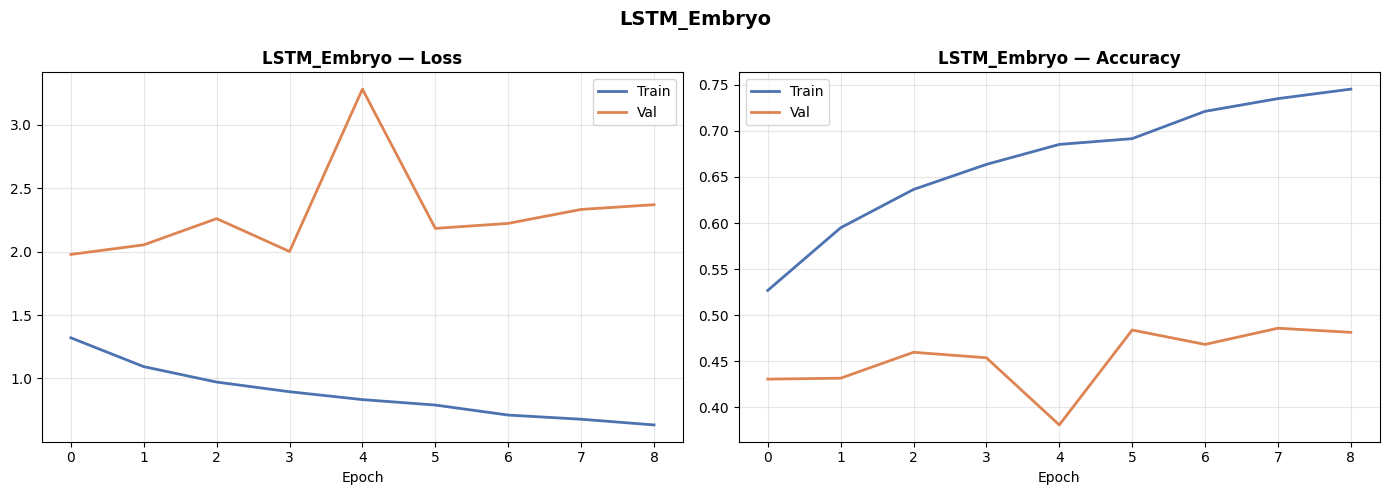


=== Evaluating: LSTM_Embryo ===


Inference:   0%|          | 0/1419 [00:00<?, ?it/s]

              precision    recall  f1-score   support

        pPB2     0.3326    0.7045    0.4518      1005
        pPNa     0.8520    0.5967    0.7018      5539
        pPNf     0.2621    0.3951    0.3151       906
          p2     0.7301    0.6225    0.6720      3759
          p3     0.1301    0.1127    0.1208       790
          p4     0.4270    0.4010    0.4136      3623
          p5     0.0855    0.0672    0.0753      1295
          p6     0.0419    0.0514    0.0462       953
          p7     0.1630    0.2065    0.1822      2213
          p8     0.5107    0.2431    0.3294      5101
         p9+     0.5970    0.4557    0.5168      7626
          pM     0.1958    0.4472    0.2723      2558
         pSB     0.3265    0.3366    0.3315      3500
          pB     0.2503    0.1543    0.1909      1497
         pEB     0.5187    0.7204    0.6031      5029

   micro avg     0.4360    0.4348    0.4354     45394
   macro avg     0.3615    0.3677    0.3482     45394
weighted avg     0.4842   

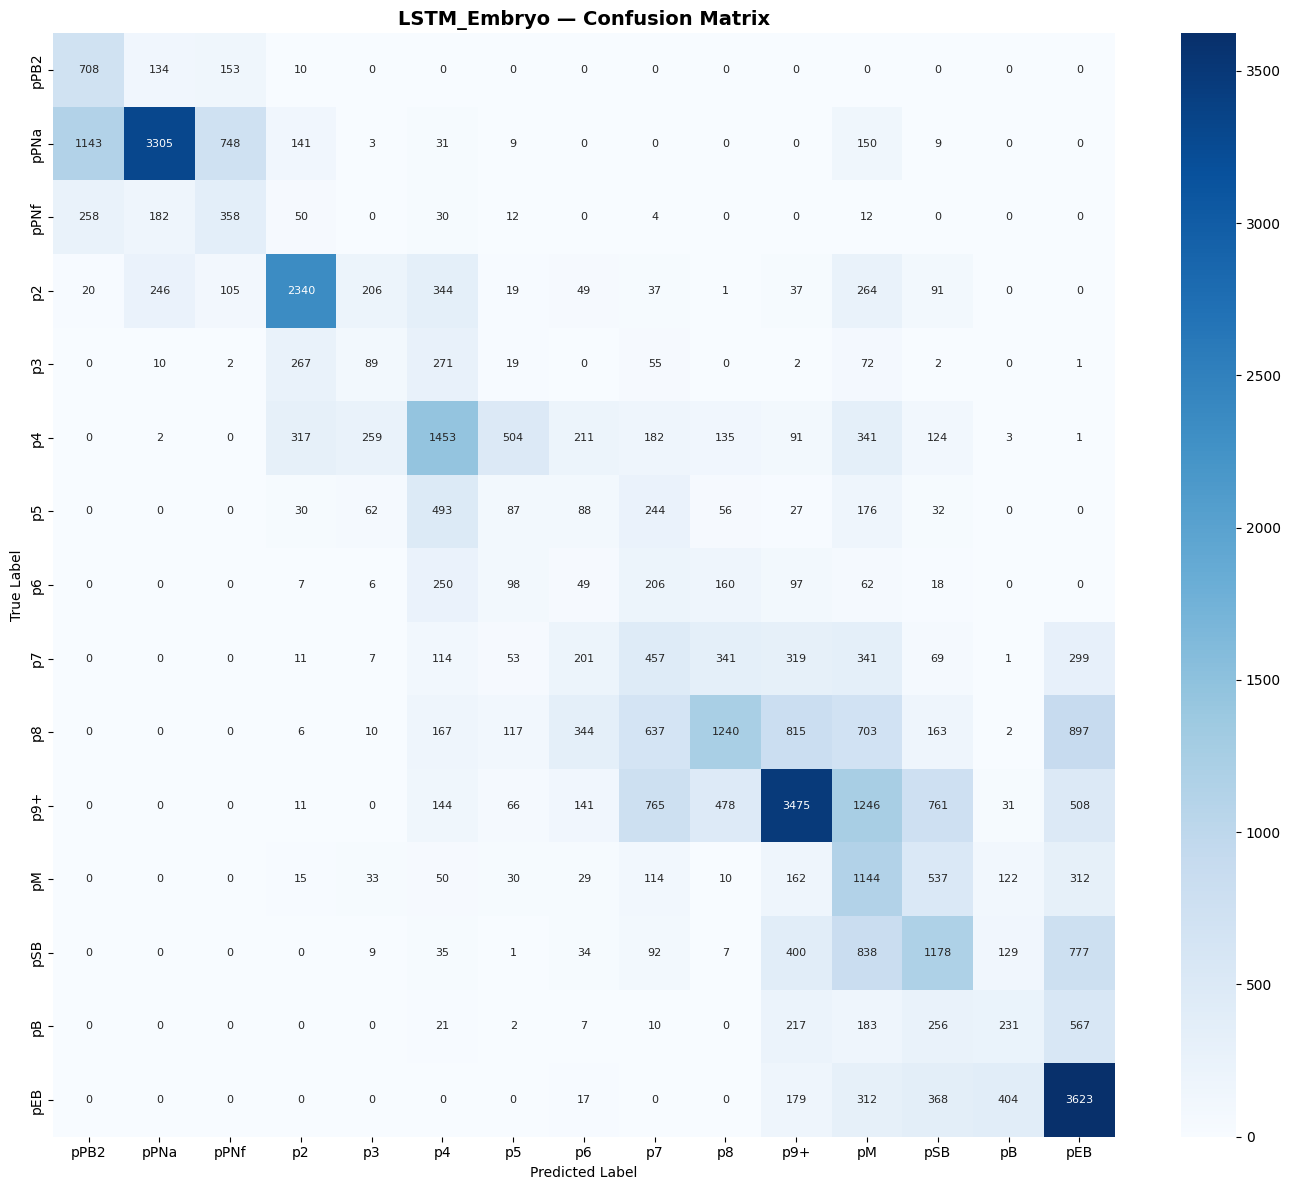

Macro ROC-AUC : 0.8762
Test Accuracy : 0.4348


In [11]:
plot_history('LSTM_Embryo')
metrics = evaluate_model(model, test_ds, 'LSTM_Embryo')


---
## 🎞️ Section 11 — Sequence Prediction Visualiser
Shows the 6 input frames for a sample sequence and what the model predicted.

=== Sequence Prediction Visualisations ===


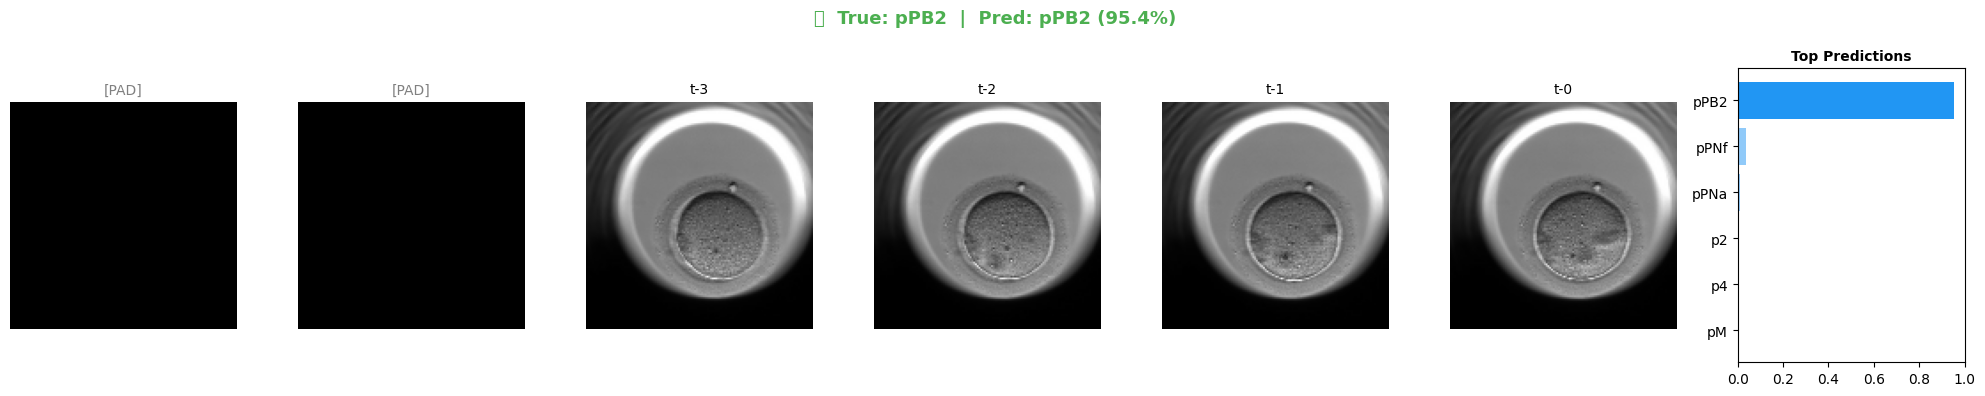

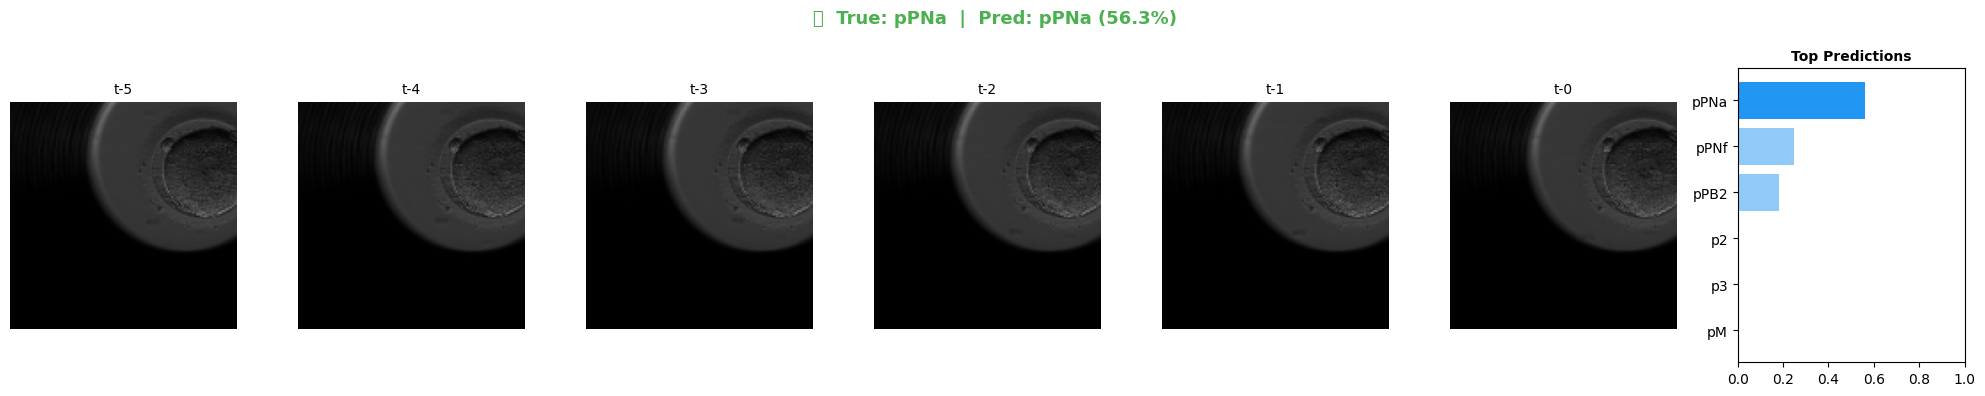

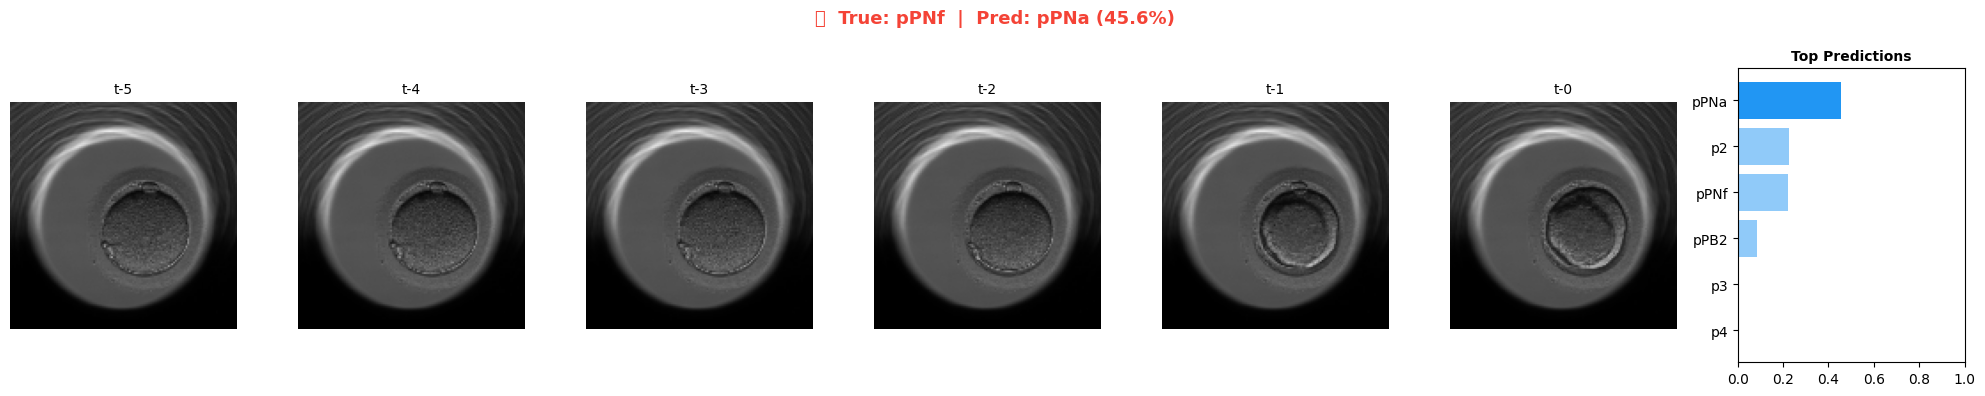

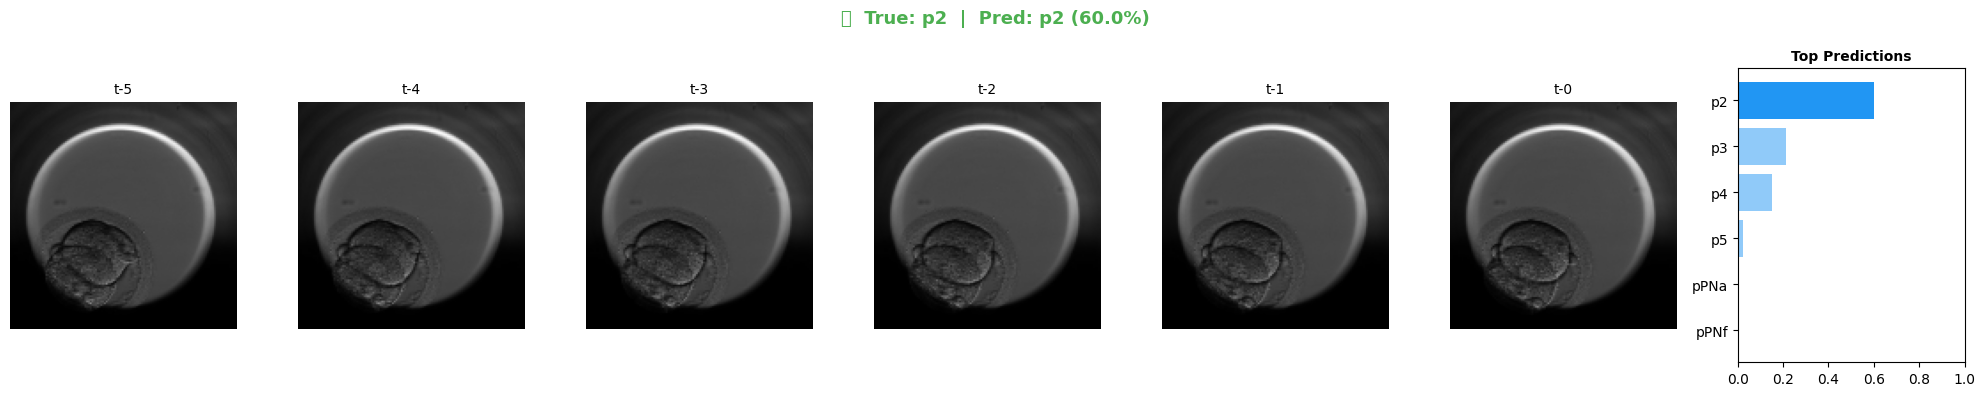

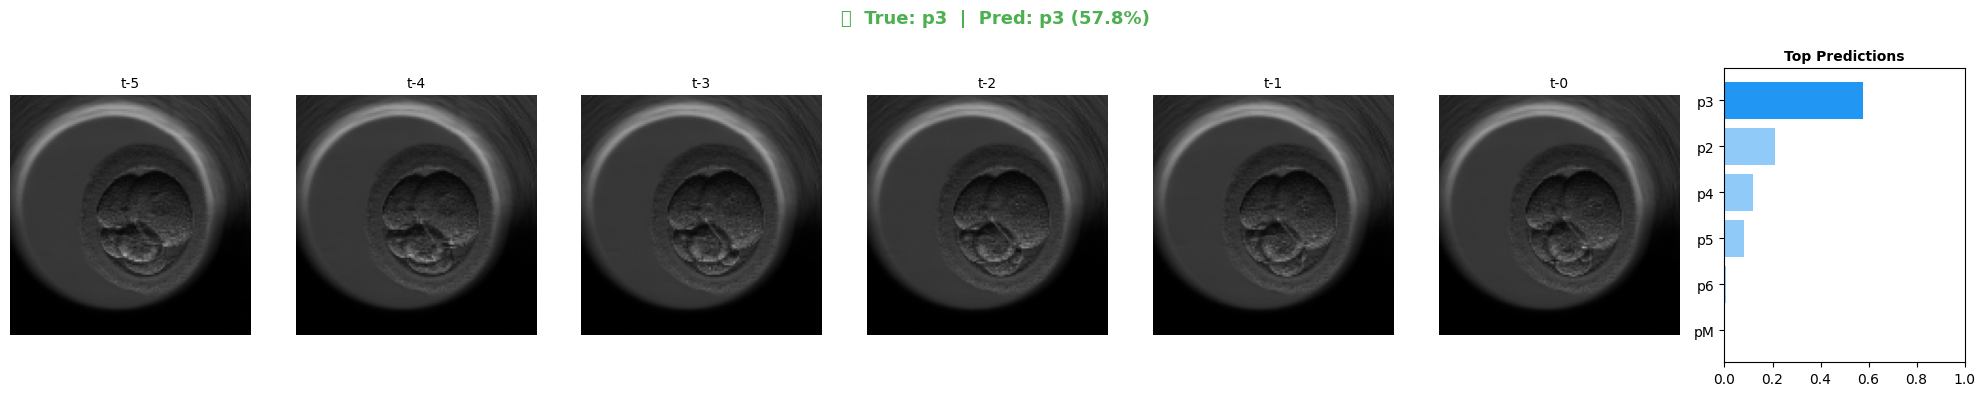

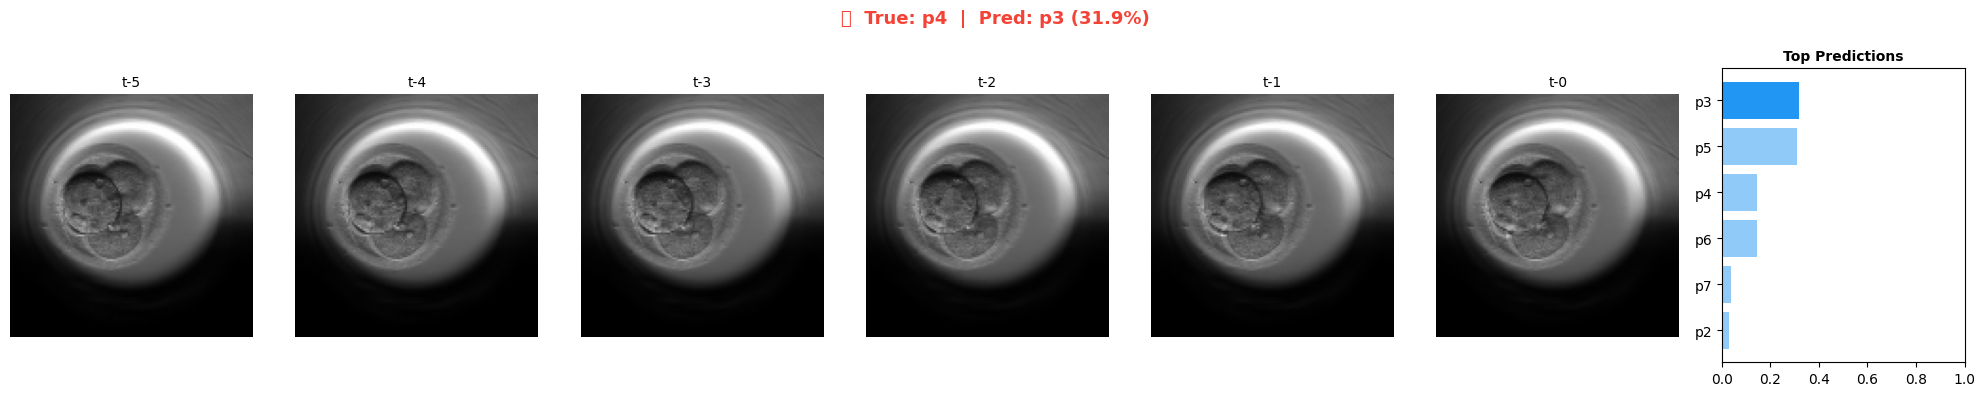

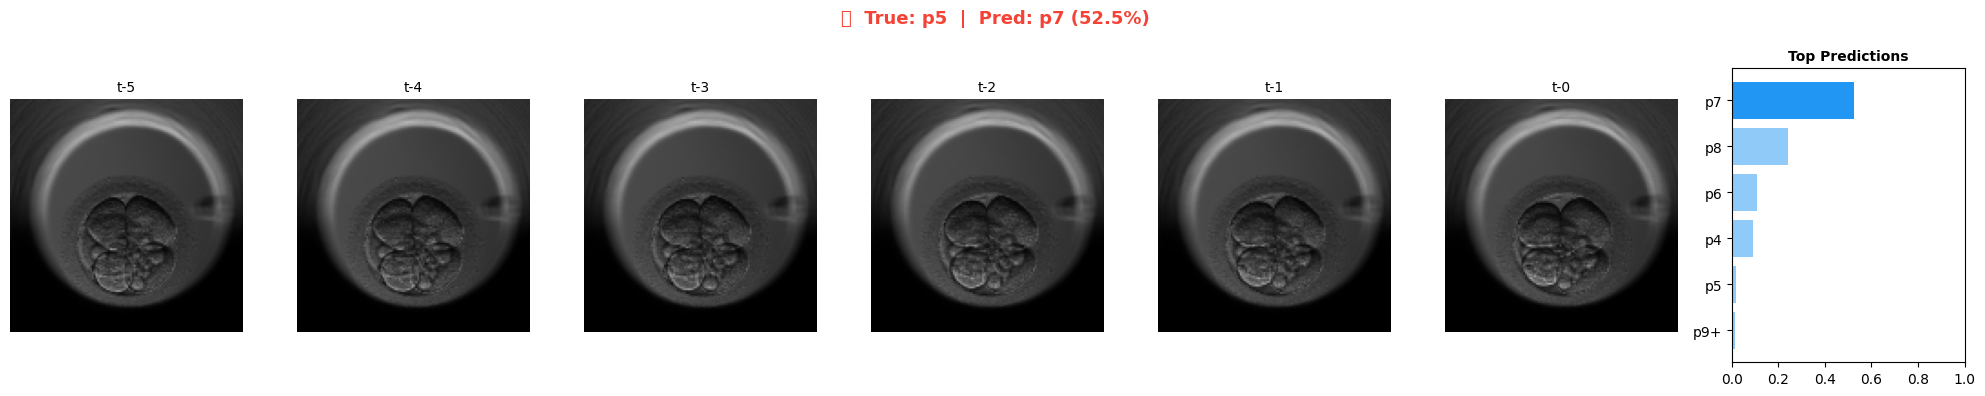

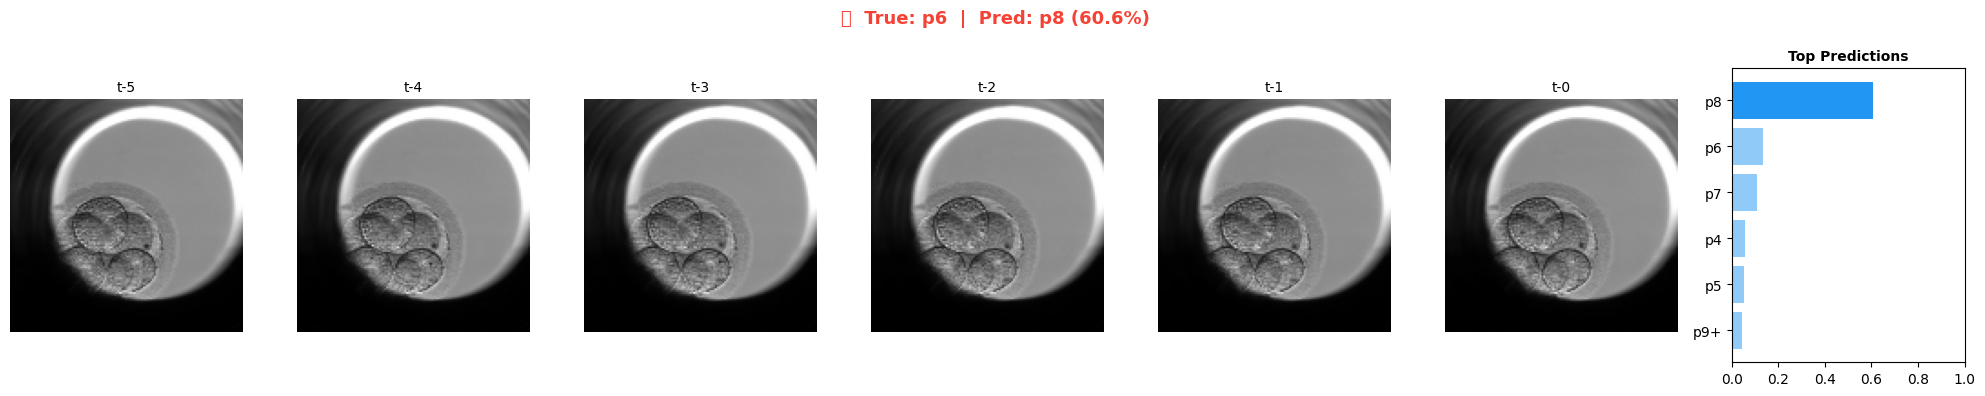

Showed 8 sequence predictions.


In [12]:
def visualise_sequence_prediction(seq_paths, true_label, model, img_size=IMG_SIZE):
    """Display all frames in a sequence with the model's prediction."""
    frames_display = []
    frames_model   = []

    for fp in seq_paths:
        if fp == '':
            frames_display.append(np.zeros((*img_size, 3)))
            frames_model.append(np.zeros((*img_size, 3), dtype=np.float32))
        else:
            raw  = tf.io.read_file(fp)
            img  = tf.image.decode_jpeg(raw, channels=1, try_recover_truncated=True)
            img  = tf.image.grayscale_to_rgb(img)
            img  = tf.image.resize(img, img_size)
            img_f = tf.cast(img, tf.float32).numpy()
            frames_display.append(img_f / 255.0)
            frames_model.append(img_f)

    inp   = tf.expand_dims(tf.stack(frames_model), 0)          # (1, SEQ_LEN, H, W, 3)
    probs = model(inp, training=False).numpy()[0]              # (NUM_CLASSES,)
    pred_idx  = int(np.argmax(probs))
    pred_conf = float(probs[pred_idx])

    fig, axes = plt.subplots(1, SEQ_LEN + 1, figsize=(20, 4))
    for t, (ax, frame) in enumerate(zip(axes[:SEQ_LEN], frames_display)):
        ax.imshow(frame)
        is_pad = seq_paths[t] == ''
        ax.set_title(f't-{SEQ_LEN-1-t}' if not is_pad else '[PAD]',
                     fontsize=10, color='gray' if is_pad else 'black')
        ax.axis('off')
        if t == SEQ_LEN - 1:
            for spine in ax.spines.values():
                spine.set_edgecolor('#2196F3'); spine.set_linewidth(3)

    # Probability bar chart
    top_n   = 6
    top_idx = np.argsort(probs)[::-1][:top_n]
    axes[-1].barh([PHASE_LABELS[i] for i in top_idx[::-1]],
                  [probs[i] for i in top_idx[::-1]],
                  color=['#2196F3' if i == pred_idx else '#90CAF9' for i in top_idx[::-1]])
    axes[-1].set_title('Top Predictions', fontsize=10, fontweight='bold')
    axes[-1].set_xlim(0, 1)
    axes[-1].axvline(x=0, color='black', lw=0.5)

    color = '#4CAF50' if pred_idx == true_label else '#F44336'
    status = '✅' if pred_idx == true_label else '❌'
    fig.suptitle(
        f'{status}  True: {PHASE_LABELS[true_label]}  |  '
        f'Pred: {PHASE_LABELS[pred_idx]} ({pred_conf*100:.1f}%)',
        fontsize=13, fontweight='bold', color=color
    )
    plt.tight_layout()
    plt.show()


# Show one sample per class (first 8 classes)
print('=== Sequence Prediction Visualisations ===')
shown = 0
for cls_idx in range(min(8, NUM_CLASSES)):
    subset = test_seq[test_seq['label_idx'] == cls_idx]
    if len(subset) == 0: continue
    row = subset.sample(1, random_state=SEED).iloc[0]
    visualise_sequence_prediction(row['seq'], row['label_idx'], model)
    shown += 1

print(f'Showed {shown} sequence predictions.')


---
## 💾 Section 12 — Final Summary

In [13]:
print('=== Checkpoints ===')
for f in sorted(CKPT_DIR.glob('*.keras')):
    print(f'  {f.name:50s}  {f.stat().st_size/1e6:.1f} MB')

print('\n=== Result Files ===')
for f in sorted(RESULTS_DIR.iterdir()):
    print(f'  {f.name}')

print('\n' + '='*55)
print('  LSTM EMBRYO CLASSIFICATION — FINAL RESULTS')
print('='*55)
print(f'  Model          : LSTM + MobileNetV2 extractor')
print(f'  Sequence length: {SEQ_LEN} frames')
print(f'  Classes        : {NUM_CLASSES}')
print(f'  Test Accuracy  : {metrics["accuracy"]:.4f}')
if metrics["macro_roc_auc"]:
    print(f'  Macro ROC-AUC  : {metrics["macro_roc_auc"]:.4f}')
print('='*55)
print('\n✅ Experiment complete!')


=== Checkpoints ===
  LSTM_Embryo_best.keras                              45.8 MB

=== Result Files ===
  LSTM_Embryo_cm.png
  LSTM_Embryo_curves.png
  LSTM_Embryo_report.txt
  eda_sequences.png

  LSTM EMBRYO CLASSIFICATION — FINAL RESULTS
  Model          : LSTM + MobileNetV2 extractor
  Sequence length: 6 frames
  Classes        : 16
  Test Accuracy  : 0.4348
  Macro ROC-AUC  : 0.8762

✅ Experiment complete!
